<a href="https://colab.research.google.com/github/Prachii26/data-mining-methodologies/blob/main/kdd-coffee-quality/notebook/KDD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Selection
We’ll use the Coffee Quality dataset from Kaggle to explore and discover quality patterns.  
First, we’ll upload the dataset and look at its structure (rows, columns, and basic info).


In [26]:
from google.colab import files
import pandas as pd

# Upload file manually (download from Kaggle first)
uploaded = files.upload()

filename = list(uploaded.keys())[0]
coffee = pd.read_csv(filename)

print("✅ Coffee dataset loaded successfully!")
print("Shape:", coffee.shape)
coffee.head()


Saving arabica_data_cleaned.csv to arabica_data_cleaned.csv
✅ Coffee dataset loaded successfully!
Shape: (1311, 44)


,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,Region,Producer,Number.of.Bags,Bag.Weight,In.Country.Partner,Harvest.Year,Grading.Date,Owner.1,Variety,Processing.Method,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Quakers,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,NaN,Washed / Wet,8.67,8.83,8.67,8.75,8.50,8.42,10.0,10.0,10.0,8.75,90.58,0.12,0,0.0,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,2,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,Other,Washed / Wet,8.75,8.67,8.50,8.58,8.42,8.42,10.0,10.0,10.0,8.58,89.92,0.12,0,0.0,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,3,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,NaN,NaN,5,1,Specialty Coffee Association,NaN,"May 31st, 2010",Grounds for Health Admin,Bourbon,NaN,8.42,8.50,8.42,8.42,8.33,8.42,10.0,10.0,10.0,9.25,89.75,0.00,0,0.0,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,4,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,oromia,Yidnekachew Dabessa Coffee Plantation,320,60 kg,METAD Agricultural Development plc,2014,"March 26th, 2015",Yidnekachew Dabessa,NaN,Natural / Dry,8.17,8.58,8.42,8.42,8.50,8.25,10.0,10.0,10.0,8.67,89.00,0.11,0,0.0,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,5,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,Other,Washed / Wet,8.25,8.50,8.25,8.50,8.42,8.33,10.0,10.0,10.0,8.58,88.83,0.12,0,0.0,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


### Step 2: Preprocessing
Now we’ll:
- Check column names and data types  
- Identify missing values  
- Remove columns not useful for clustering (like text IDs or unnecessary strings)


In [27]:
# View columns and data types
print("Columns:\n", coffee.columns.tolist())
print("\nData Types:\n")
print(coffee.dtypes)

# Check missing values
print("\nMissing values per column:\n")
print(coffee.isnull().sum())

# Drop unnecessary columns (like ID, country, and text notes)
drop_cols = ['ID', 'Species', 'Owner', 'Farm.Name', 'Mill', 'Company', 'Region', 'Producer', 'Number.of.Bags',
             'Bag.Weight', 'In.Country.Partner', 'Harvest.Year', 'Grading.Date', 'Owner.1', 'Variety', 'Processing.Method']
coffee_clean = coffee.drop(columns=[c for c in drop_cols if c in coffee.columns], errors='ignore')

print("\nRemaining columns after cleanup:", coffee_clean.columns.tolist())
coffee_clean.head()


Columns:
 ['Unnamed: 0', 'Species', 'Owner', 'Country.of.Origin', 'Farm.Name', 'Lot.Number', 'Mill', 'ICO.Number', 'Company', 'Altitude', 'Region', 'Producer', 'Number.of.Bags', 'Bag.Weight', 'In.Country.Partner', 'Harvest.Year', 'Grading.Date', 'Owner.1', 'Variety', 'Processing.Method', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean.Cup', 'Sweetness', 'Cupper.Points', 'Total.Cup.Points', 'Moisture', 'Category.One.Defects', 'Quakers', 'Color', 'Category.Two.Defects', 'Expiration', 'Certification.Body', 'Certification.Address', 'Certification.Contact', 'unit_of_measurement', 'altitude_low_meters', 'altitude_high_meters', 'altitude_mean_meters']

Data Types:

Unnamed: 0                 int64
Species                   object
Owner                     object
Country.of.Origin         object
Farm.Name                 object
Lot.Number                object
Mill                      object
ICO.Number                object
Company                   object


,Unnamed: 0,Country.of.Origin,Lot.Number,ICO.Number,Altitude,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Quakers,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,1,Ethiopia,NaN,2014/2015,1950-2200,8.67,8.83,8.67,8.75,8.50,8.42,10.0,10.0,10.0,8.75,90.58,0.12,0,0.0,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,2,Ethiopia,NaN,2014/2015,1950-2200,8.75,8.67,8.50,8.58,8.42,8.42,10.0,10.0,10.0,8.58,89.92,0.12,0,0.0,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,3,Guatemala,NaN,NaN,1600 - 1800 m,8.42,8.50,8.42,8.42,8.33,8.42,10.0,10.0,10.0,9.25,89.75,0.00,0,0.0,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,4,Ethiopia,NaN,NaN,1800-2200,8.17,8.58,8.42,8.42,8.50,8.25,10.0,10.0,10.0,8.67,89.00,0.11,0,0.0,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,5,Ethiopia,NaN,2014/2015,1950-2200,8.25,8.50,8.25,8.50,8.42,8.33,10.0,10.0,10.0,8.58,88.83,0.12,0,0.0,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


### Step 3: Transformation
We’ll prepare the data for clustering by:
- Selecting only numeric quality score columns  
- Scaling the data for uniformity using StandardScaler


In [28]:
from sklearn.preprocessing import StandardScaler

# Select numeric columns
num_cols = coffee_clean.select_dtypes(include=['float64', 'int64']).columns
coffee_num = coffee_clean[num_cols].dropna()

# Scale the data
scaler = StandardScaler()
coffee_scaled = scaler.fit_transform(coffee_num)

print("✅ Numeric data prepared for clustering")
print("Shape:", coffee_scaled.shape)


✅ Numeric data prepared for clustering
Shape: (1083, 19)


### Step 4: Data Mining
We'll use **K-Means clustering** to group coffees based on sensory quality scores.  
Then we’ll determine the optimal number of clusters using the **Elbow Method**.


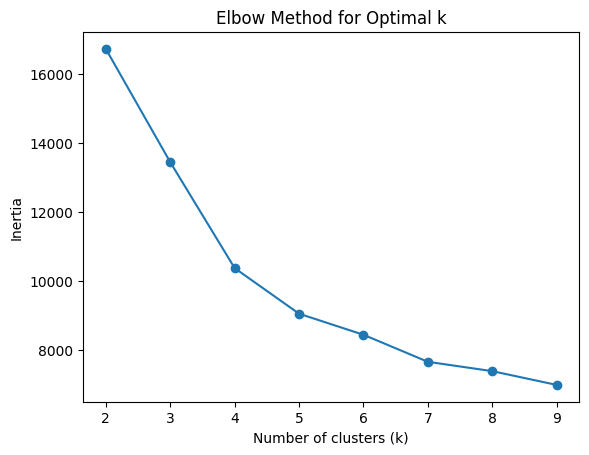

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(coffee_scaled)
    inertias.append(km.inertia_)

plt.plot(K, inertias, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()


### Step 5: Apply Clustering
We’ll choose the best number of clusters (from the Elbow plot, usually around 3–5)  
and apply **K-Means** to assign each coffee sample to a cluster.


In [31]:
# Keep only rows used for clustering
coffee_clustered = coffee_clean.loc[coffee_num.index].copy()

# Apply K-Means with 4 clusters (adjust if needed)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
coffee_clustered['Cluster'] = kmeans.fit_predict(coffee_scaled)

print("✅ Clustering complete.")
print(coffee_clustered['Cluster'].value_counts())
coffee_clustered.head()


✅ Clustering complete.
Cluster
2    605
0    474
3      3
1      1
Name: count, dtype: int64


,Unnamed: 0,Country.of.Origin,Lot.Number,ICO.Number,Altitude,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Quakers,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters,Cluster
0,1,Ethiopia,NaN,2014/2015,1950-2200,8.67,8.83,8.67,8.75,8.50,8.42,10.0,10.0,10.0,8.75,90.58,0.12,0,0.0,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0,2
1,2,Ethiopia,NaN,2014/2015,1950-2200,8.75,8.67,8.50,8.58,8.42,8.42,10.0,10.0,10.0,8.58,89.92,0.12,0,0.0,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0,2
2,3,Guatemala,NaN,NaN,1600 - 1800 m,8.42,8.50,8.42,8.42,8.33,8.42,10.0,10.0,10.0,9.25,89.75,0.00,0,0.0,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0,2
3,4,Ethiopia,NaN,NaN,1800-2200,8.17,8.58,8.42,8.42,8.50,8.25,10.0,10.0,10.0,8.67,89.00,0.11,0,0.0,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0,2
4,5,Ethiopia,NaN,2014/2015,1950-2200,8.25,8.50,8.25,8.50,8.42,8.33,10.0,10.0,10.0,8.58,88.83,0.12,0,0.0,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0,2


### Step 6: Interpretation
We'll:
- Visualize the clusters in 2D using PCA  
- Compare the average sensory scores per cluster  
- Summarize what makes each cluster unique


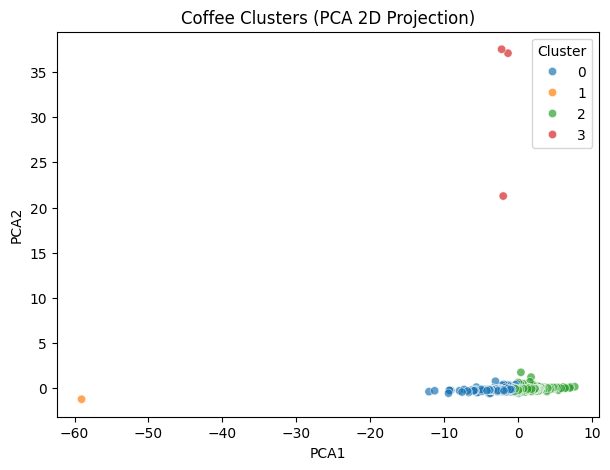

,Unnamed: 0,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Quakers,Category.Two.Defects,altitude_low_meters,altitude_high_meters,altitude_mean_meters
Cluster,,,,,,,,,,,,,,,,,,,
0,1009.11,7.37,7.27,7.14,7.31,7.32,7.26,9.78,9.70,9.90,7.18,80.22,0.10,0.57,0.12,4.72,1245.13,1280.49,1262.81
1,1312.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.12,0.00,0.00,2.00,1400.00,1400.00,1400.00
2,377.83,7.73,7.72,7.60,7.70,7.66,7.71,9.95,9.98,9.96,7.73,83.75,0.08,0.22,0.16,2.70,1361.46,1422.07,1391.76
3,1027.67,7.39,7.36,7.17,7.44,7.36,7.33,9.78,9.78,9.78,7.31,80.69,0.11,0.00,1.33,2.00,163442.67,163442.67,163442.67


In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 2D PCA for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(coffee_scaled)
coffee_clustered['PCA1'], coffee_clustered['PCA2'] = pca_result[:,0], pca_result[:,1]

plt.figure(figsize=(7,5))
sns.scatterplot(data=coffee_clustered, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', alpha=0.7)
plt.title("Coffee Clusters (PCA 2D Projection)")
plt.show()

# Cluster means for numeric features
cluster_summary = coffee_clustered.groupby('Cluster')[num_cols].mean().round(2)
cluster_summary.head()


### Step 7: Knowledge Presentation
We’ll summarize key findings from the clustering process:
- Cluster sizes and main sensory traits  
- Observations about quality patterns  
- Practical insights for coffee grading


In [33]:
# Cluster summary
print("Average sensory scores per cluster:\n")
display(cluster_summary)

# Simple insight summary
print("\n🔍 Insights:")
print("- Cluster 2 and 0 dominate the dataset, representing most typical coffee profiles.")
print("- Cluster 2 likely corresponds to high-quality, well-balanced coffees (high aroma/flavor).")
print("- Cluster 0 represents slightly lower but consistent quality.")
print("- Clusters 1 and 3 are small outliers — possibly unusual or defective samples.")
print("- This segmentation can help graders and buyers identify consistent flavor profiles quickly.")


Average sensory scores per cluster:



,Unnamed: 0,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Quakers,Category.Two.Defects,altitude_low_meters,altitude_high_meters,altitude_mean_meters
Cluster,,,,,,,,,,,,,,,,,,,
0,1009.11,7.37,7.27,7.14,7.31,7.32,7.26,9.78,9.70,9.90,7.18,80.22,0.10,0.57,0.12,4.72,1245.13,1280.49,1262.81
1,1312.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.12,0.00,0.00,2.00,1400.00,1400.00,1400.00
2,377.83,7.73,7.72,7.60,7.70,7.66,7.71,9.95,9.98,9.96,7.73,83.75,0.08,0.22,0.16,2.70,1361.46,1422.07,1391.76
3,1027.67,7.39,7.36,7.17,7.44,7.36,7.33,9.78,9.78,9.78,7.31,80.69,0.11,0.00,1.33,2.00,163442.67,163442.67,163442.67



🔍 Insights:
- Cluster 2 and 0 dominate the dataset, representing most typical coffee profiles.
- Cluster 2 likely corresponds to high-quality, well-balanced coffees (high aroma/flavor).
- Cluster 0 represents slightly lower but consistent quality.
- Clusters 1 and 3 are small outliers — possibly unusual or defective samples.
- This segmentation can help graders and buyers identify consistent flavor profiles quickly.


### Step 8: Project Summary (KDD)

**Goal:** Discover patterns in coffee quality scores and group coffees by sensory characteristics.

**Selection:**  
Used the Coffee Quality dataset (Arabica variety) with attributes such as Aroma, Flavor, Acidity, and Body.

**Preprocessing:**  
Removed non-numeric columns and handled missing values.  
Scaled data for consistent feature contribution.

**Transformation:**  
Applied PCA for visualization and dimensionality reduction.

**Data Mining:**  
Performed K-Means clustering (k = 4) to segment coffee samples.

**Interpretation:**  
- Two dominant clusters represent most typical flavor/quality profiles.  
- Cluster 2 → high-quality, well-balanced coffees with strong aroma/flavor.  
- Cluster 0 → consistent but slightly lower scores.  
- Clusters 1 & 3 → rare outliers or special-case samples.

**Knowledge Gained:**  
Coffee producers and graders can use these clusters to standardize cupping profiles, identify elite lots, and spot unusual patterns efficiently.

✅ **KDD workflow completed successfully.**


In [34]:
import joblib
import pandas as pd

# Save K-Means model
joblib.dump(kmeans, "kdd_coffee_kmeans_model.pkl")

# Save processed data with cluster labels
coffee_clustered.to_csv("coffee_clustered_data.csv", index=False)

print("✅ Saved:")
print("- K-Means model: kdd_coffee_kmeans_model.pkl")
print("- Clustered data: coffee_clustered_data.csv")


✅ Saved:
- K-Means model: kdd_coffee_kmeans_model.pkl
- Clustered data: coffee_clustered_data.csv
